<a href="https://colab.research.google.com/github/PALAK7890/Indian_Crime/blob/main/Crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [57]:
url='https://raw.githubusercontent.com/PALAK7890/Indian_Crime/refs/heads/main/india_crime_dataset.csv'
df=pd.read_csv(url)
df.head()

,fir_number,date_reported,year,city,state,primary_crime_type,description,ipc_section,location_type,beat_zone,victim_age,victim_gender,arrest_made,case_status,severity,latitude,longitude
0,fir/pun/2015/4628,05 May 2015 04:56 PM,2015,Pune,Maharashtra,VEHICLE THEFT,Two Wheeler,IPC 379,Street,NaN,54.0,Male,NaN,CHARGE SHEETED,Low,18.602007,73.963196
1,FIR/AHM/2021/2730,08/02/2021 13:57:00,2021,Ahmedabad,Gujarat,VEHICLE THEFT,Car Theft,ipc 379,MARKET,23.0,63.0,MALE,No,Closed,Low,23.157595,72.713810
2,PUN-2017-4991,14/10/2017 16:19:00,2017,Pune,Maharashtra,COUNTERFEITING,fake currency,489A IPC,Residence,18.0,58.0,Male,no,Under Investigation,Low,18.425002,73.793409
3,FIR/MUM/2017/9525,13/08/17 13:11,2017,Mumbai,Maharashtra,FRAUD/CHEATING,UPI Fraud,IPC-420,ATM,8.0,26.0,FEMALE,yes,Pending Trial,Low,19.070575,72.949740
4,FIR92792023,28/10/2023 23:58:00,2023,Mumbai,Maharashtra,KIDNAPPING,Abduction for Ransom,IPC 363,SCHOOL,20.0,7.0,m,NaN,under investigation,High,18.927087,72.858727


In [58]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fir_number          60000 non-null  object 
 1   date_reported       60000 non-null  object 
 2   year                60000 non-null  int64  
 3   city                60000 non-null  object 
 4   state               60000 non-null  object 
 5   primary_crime_type  60000 non-null  object 
 6   description         60000 non-null  object 
 7   ipc_section         60000 non-null  object 
 8   location_type       56722 non-null  object 
 9   beat_zone           55784 non-null  float64
 10  victim_age          54616 non-null  float64
 11  victim_gender       53331 non-null  object 
 12  arrest_made         46136 non-null  object 
 13  case_status         55938 non-null  object 
 14  severity            60000 non-null  object 
 15  latitude            54036 non-null  float64
 16  long

In [59]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57000 entries, 0 to 59998
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fir_number          57000 non-null  object 
 1   date_reported       57000 non-null  object 
 2   year                57000 non-null  int64  
 3   city                57000 non-null  object 
 4   state               57000 non-null  object 
 5   primary_crime_type  57000 non-null  object 
 6   description         57000 non-null  object 
 7   ipc_section         57000 non-null  object 
 8   location_type       53910 non-null  object 
 9   beat_zone           53010 non-null  float64
 10  victim_age          51880 non-null  float64
 11  victim_gender       50652 non-null  object 
 12  arrest_made         43861 non-null  object 
 13  case_status         53136 non-null  object 
 14  severity            57000 non-null  object 
 15  latitude            51336 non-null  float64
 16  longitude

In [61]:
df.shape

(57000, 17)

<Axes: >

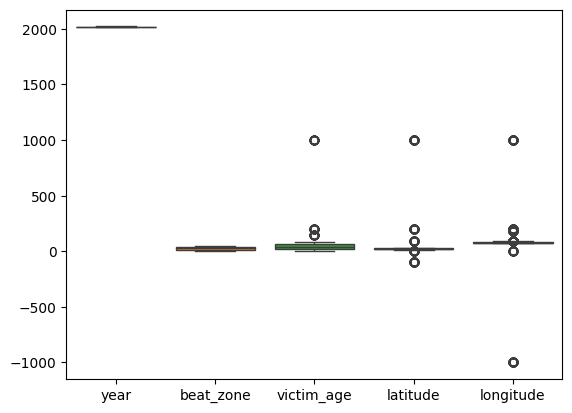

In [62]:
df_num=df.select_dtypes(include='number')
sns.boxplot(data=df_num)

<Axes: ylabel='victim_age'>

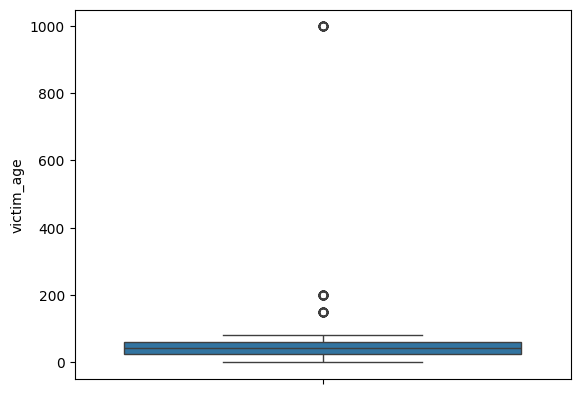

In [63]:
sns.boxplot(data=df['victim_age'])

In [64]:
df['victim_age'].describe()

,victim_age
count,51880.000000
mean,42.678065
std,31.461715
min,-1.000000
25%,23.000000
50%,42.000000
75%,61.000000
max,999.000000


In [65]:
df = df[(df['victim_age'] >= 1) & (df['victim_age'] <= 100)]
df['victim_age'].describe()

,victim_age
count,51730.000000
mean,42.027740
std,21.689746
min,5.000000
25%,23.000000
50%,42.000000
75%,61.000000
max,79.000000


In [66]:
df['longitude'].describe()

,longitude
count,46563.000000
mean,78.262954
std,50.921377
min,-999.000000
25%,73.930352
50%,77.301812
75%,80.235602
max,999.000000


In [67]:
print((df['longitude'] > 180).sum())
print((df['longitude'] < -180).sum())

177
55


In [68]:
df = df[(df['longitude'] >= -180) & (df['longitude'] <= 180)]

In [69]:
df['longitude'].describe()

,longitude
count,46331.000000
mean,77.997603
std,5.150349
min,0.000000
25%,73.929988
50%,77.289129
75%,80.227071
max,91.885773


In [70]:
df['latitude'].describe()

,latitude
count,46331.000000
mean,21.457324
std,15.509502
min,-99.000000
25%,17.527804
50%,21.237167
75%,26.394056
max,999.000000


In [71]:
df = df[(df['latitude'] >= -90) & (df['latitude'] <= 90)]
df['latitude'].describe()

,latitude
count,46303.000000
mean,21.234375
std,5.365515
min,0.000000
25%,17.527676
50%,21.236368
75%,26.390990
max,30.882288


In [72]:
df = df[(df['latitude'] != 0) & (df['longitude'] != 0)]

<Axes: >

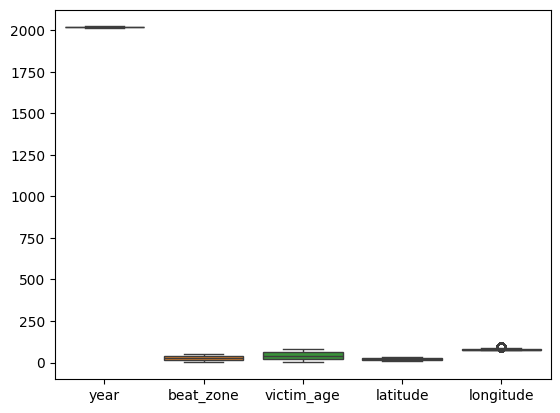

In [73]:
df_num=df.select_dtypes(include='number')
sns.boxplot(data=df_num)

In [75]:
df['victim_age']=df['victim_age'].fillna(df['victim_age'].median())
df['victim_age'] = df['victim_age'].astype(int)
df['beat_zone'] = df['beat_zone'].fillna(df['beat_zone'].median())
df['beat_zone'] = df['beat_zone'].astype(int)


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46294 entries, 0 to 59998
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fir_number          46294 non-null  object 
 1   date_reported       46294 non-null  object 
 2   year                46294 non-null  int64  
 3   city                46294 non-null  object 
 4   state               46294 non-null  object 
 5   primary_crime_type  46294 non-null  object 
 6   description         46294 non-null  object 
 7   ipc_section         46294 non-null  object 
 8   location_type       46294 non-null  object 
 9   beat_zone           46294 non-null  int64  
 10  victim_age          46294 non-null  int64  
 11  victim_gender       46294 non-null  object 
 12  arrest_made         46294 non-null  bool   
 13  case_status         46294 non-null  object 
 14  severity            46294 non-null  object 
 15  latitude            46294 non-null  float64
 16  longitude

In [113]:

df['date_reported'] = pd.to_datetime(
    df['date_reported'],
    errors='coerce',
    dayfirst=True
)
df['date_reported'] = df['date_reported'].dt.strftime('%Y-%m-%d')


In [123]:
df['ipc_section'].value_counts()

,count
ipc_section,
ipc 378,1408
378 IPC,1403
Sec 378,1399
IPC 378,1371
378,1370
...,...
IPC 435,108
IPC 436,107
ipc 370,105


In [81]:
df['arrest_made'] = df['arrest_made'].astype(str).str.strip().str.lower()

df['arrest_made'] = df['arrest_made'].map({
    'yes': True, 'y': True, 'true': True,
    'no': False, 'n': False, 'false': False
})
df['arrest_made']=df['arrest_made'].fillna(df['arrest_made'].mode()[0])

/tmp/ipykernel_374/4220669320.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['arrest_made']=df['arrest_made'].fillna(df['arrest_made'].mode()[0])


In [86]:
df['case_status']=df['case_status'].str.lower()
df['case_status']=df['case_status'].fillna(df['case_status'].mode()[0])

In [91]:
df['location_type']=df['location_type'].str.lower()
df['location_type']=df['location_type'].fillna(df['location_type'].mode()[0])

In [97]:
df['victim_gender']=df['victim_gender'].str.lower()
df['victim_gender'] = df['victim_gender'].map({
    'male': 'male', 'm': 'male',
    'female': 'female', 'f': 'female'
})
df['victim_gender'] = df['victim_gender'].fillna('Unknown')

In [120]:
df['description']=df['description'].str.lower()


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46294 entries, 0 to 59998
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fir_number          46294 non-null  object 
 1   date_reported       46294 non-null  object 
 2   year                46294 non-null  int64  
 3   city                46294 non-null  object 
 4   state               46294 non-null  object 
 5   primary_crime_type  46294 non-null  object 
 6   description         46294 non-null  object 
 7   ipc_section         46294 non-null  object 
 8   location_type       46294 non-null  object 
 9   beat_zone           46294 non-null  int64  
 10  victim_age          46294 non-null  int64  
 11  victim_gender       46294 non-null  object 
 12  arrest_made         46294 non-null  bool   
 13  case_status         46294 non-null  object 
 14  severity            46294 non-null  object 
 15  latitude            46294 non-null  float64
 16  longitude